In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (8, 6)
sns.set_style('whitegrid')

# Load dataset
df = pd.read_csv('loans_dataset.csv')
print(f"Data Shape before filtering: {df.shape}")

Data Shape before filtering: (10000, 55)


In [2]:
# Subset required variables
cols = [
    'interest_rate', 'verified_income', 'debt_to_income',
    'total_credit_utilized', 'total_credit_limit', 'public_record_bankrupt',
    'loan_purpose', 'term', 'inquiries_last_12m', 'issue_month',
    'annual_income', 'loan_amount', 'grade', 'emp_length', 'homeownership'
]
df = df[cols].copy()

# Rename column
df.rename(columns={'inquiries_last_12m': 'credit_checks'}, inplace=True)

print(f"Data Shape after filtering: {df.shape}")

Data Shape after filtering: (10000, 15)


In [3]:
# Summary statistics for numerical variables
num_stats = df.describe().loc[['count', 'mean', 'std', 'min', 'max']]
num_stats.round(2)

,interest_rate,debt_to_income,total_credit_utilized,total_credit_limit,public_record_bankrupt,term,credit_checks,annual_income,loan_amount,emp_length
count,10000.00,9976.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,9183.00
mean,12.43,19.31,51049.06,183606.23,0.12,43.27,1.96,79222.15,16361.92,5.93
std,5.00,15.00,53636.73,187632.71,0.34,11.03,2.38,64734.29,10301.96,3.70
min,5.31,0.00,0.00,0.00,0.00,36.00,0.00,0.00,1000.00,0.00
max,30.94,469.09,942456.00,3386034.00,3.00,60.00,29.00,2300000.00,40000.00,10.00


In [4]:
# Numerical summaries
num_vars = ['interest_rate', 'annual_income', 'debt_to_income', 'loan_amount']
desc_stats = df[num_vars].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2)
print("Descriptive Stats:\n", desc_stats)

Descriptive Stats:
         interest_rate  annual_income  debt_to_income  loan_amount
count        10000.00       10000.00         9976.00     10000.00
mean            12.43       79222.15           19.31     16361.92
median          11.98       65000.00           17.57     14500.00
std              5.00       64734.29           15.00     10301.96
min              5.31           0.00            0.00      1000.00
max             30.94     2300000.00          469.09     40000.00


In [5]:
# Categorical frequencies
cat_vars = ['grade', 'verified_income', 'homeownership']
print("Categorical frequencies\n")
for col in cat_vars:
    freq = df[col].value_counts(normalize=True).mul(100).round(1)
    print(f"\n{col} (n={df[col].nunique()} categories):\n{freq.to_string()}%")

Categorical frequencies


grade (n=7 categories):
grade
B    30.4
C    26.5
A    24.6
D    14.5
E     3.4
F     0.6
G     0.1%

verified_income (n=3 categories):
verified_income
Source Verified    41.2
Not Verified       35.9
Verified           22.9%

homeownership (n=3 categories):
homeownership
MORTGAGE    47.9
RENT        38.6
OWN         13.5%


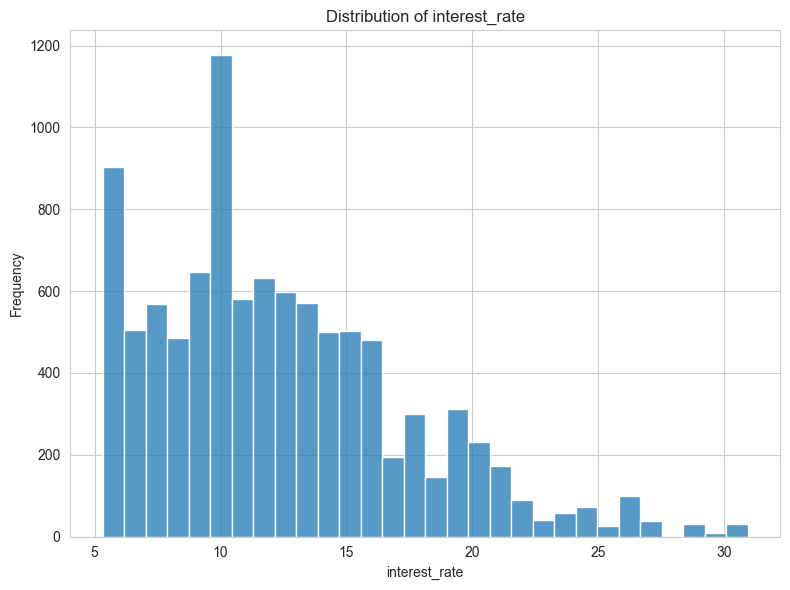

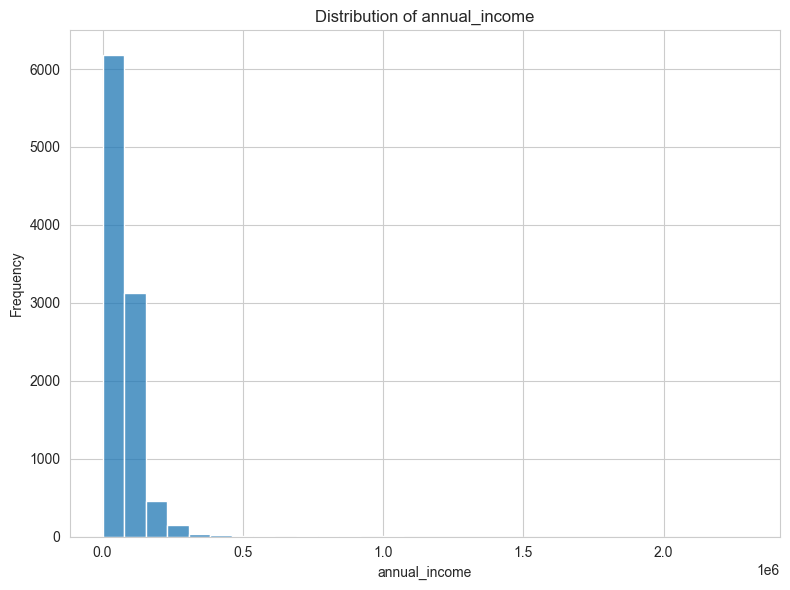

In [6]:
# Histograms
for var in ['interest_rate', 'annual_income']:
    plt.figure()
    sns.histplot(df[var].dropna(), bins=30, kde=False)
    plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.savefig(f'hist_{var}.png', dpi=150)
    plt.show()

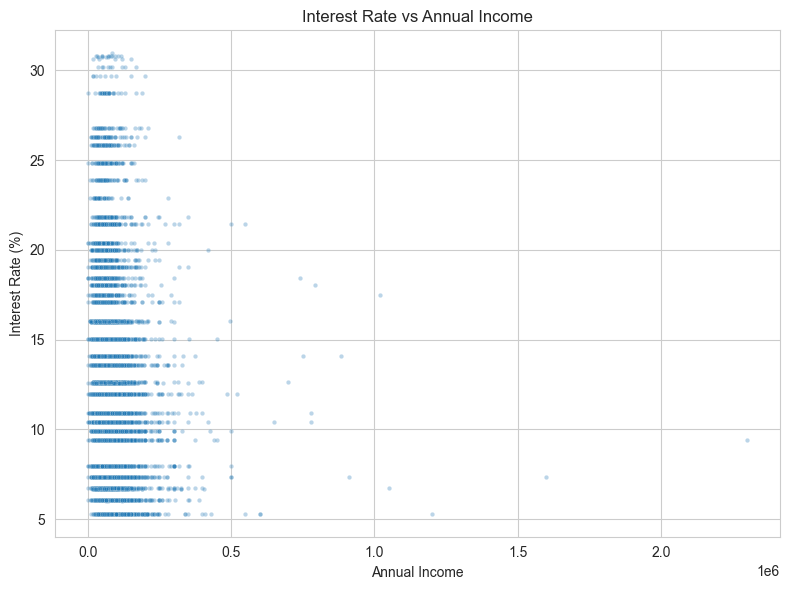

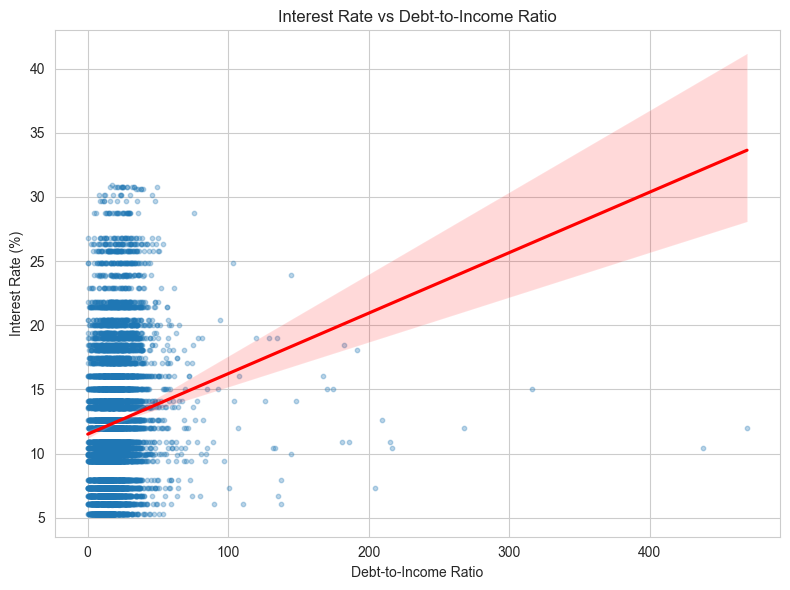

In [7]:
# interest_rate vs annual_income
plt.figure()
sns.scatterplot(x='annual_income', y='interest_rate', data=df, alpha=0.3, s=10)
plt.title('Interest Rate vs Annual Income')
plt.xlabel('Annual Income')
plt.ylabel('Interest Rate (%)')
plt.tight_layout()
plt.savefig('scatter_income.png', dpi=150)
plt.show()

# interest_rate vs debt_to_income with regression line
plt.figure()
sns.regplot(x='debt_to_income', y='interest_rate', data=df,
            scatter_kws={'alpha': 0.3, 's': 10}, line_kws={'color': 'red'})
plt.title('Interest Rate vs Debt-to-Income Ratio')
plt.xlabel('Debt-to-Income Ratio')
plt.ylabel('Interest Rate (%)')
plt.tight_layout()
plt.savefig('scatter_dti.png', dpi=150)
plt.show()

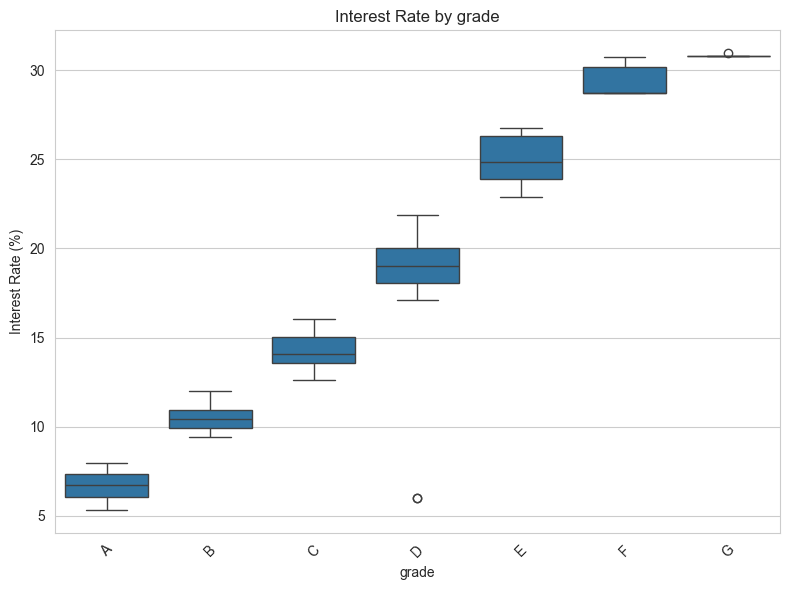

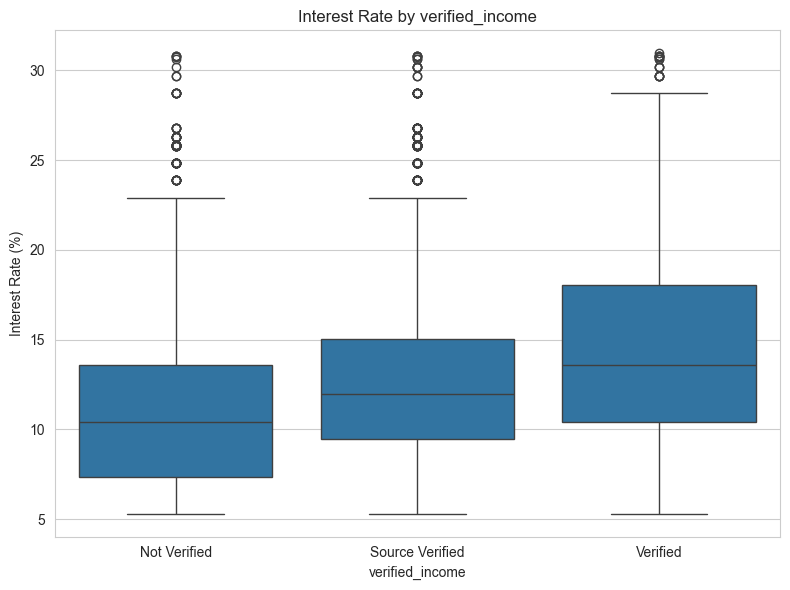

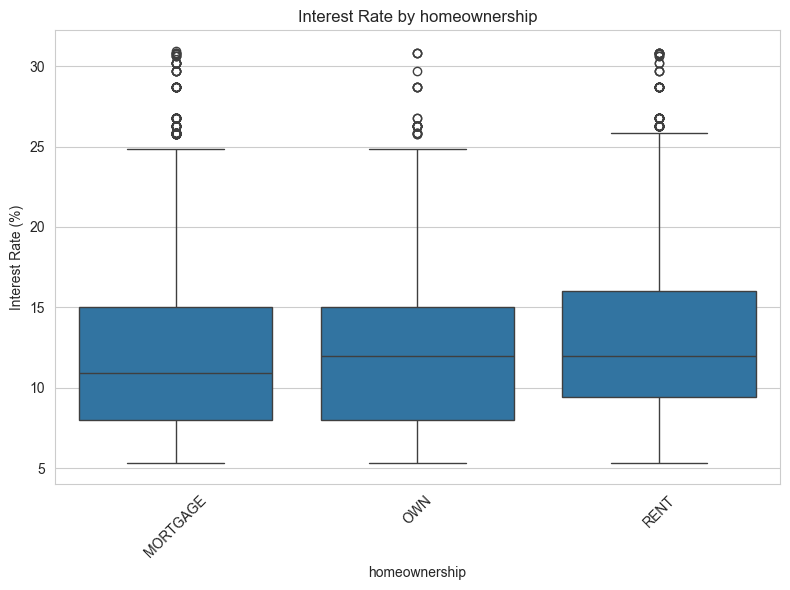

In [8]:
# Boxplots by categorical variables
for col in ['grade', 'verified_income', 'homeownership']:
    plt.figure()
    order = sorted(df[col].dropna().unique())
    sns.boxplot(x=col, y='interest_rate', data=df, order=order)
    plt.title(f'Interest Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Interest Rate (%)')
    if col in ['grade', 'homeownership']:
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'box_{col}.png', dpi=150)
    plt.show()

In [9]:
# Credit Utilization Ratio (handle div-by-zero)
df['credit_util'] = np.where(
    df['total_credit_limit'] == 0,
    0,
    df['total_credit_utilized'] / df['total_credit_limit']
)

# Bankruptcy Dummy
df['bankruptcy_dummy'] = (df['public_record_bankrupt'] >= 1).astype(int)

for var in ['credit_util', 'bankruptcy_dummy']:
    mean_val = df[var].mean()
    pct_nonzero = (df[var] != 0).mean() * 100
    print(f"{var}: Mean = {mean_val:.4f}, % Non-zero = {pct_nonzero:.2f}%")

credit_util: Mean = 0.4031, % Non-zero = 99.72%
bankruptcy_dummy: Mean = 0.1215, % Non-zero = 12.15%


In [10]:
# Variables needed for regression models
model_vars = [
    'interest_rate', 'debt_to_income', 'credit_util', 'bankruptcy_dummy',
    'annual_income', 'loan_amount', 'term', 'grade', 'emp_length',
    'homeownership', 'loan_purpose', 'credit_checks', 'verified_income'
]
df_mod = df[model_vars].dropna().reset_index(drop=True)

assert not df_mod.isnull().any().any(), "NaNs still present in modeling data"
y = df_mod['interest_rate']
print(f"Modeling sample size after dropping NaNs: {len(df_mod)}")

Modeling sample size after dropping NaNs: 9182


In [11]:
# Model 1: interest_rate = β0 + β1*debt_to_income + ε
X1 = sm.add_constant(df_mod['debt_to_income'])
model1 = sm.OLS(y, X1).fit()
print("Model 1 Summary:\n", model1.summary().tables[1])
print(f"\nFitted equation: interest_rate = {model1.params['const']:.4f} + {model1.params['debt_to_income']:.4f} * debt_to_income")
print(f"R² = {model1.rsquared:.4f} | F-stat = {model1.fvalue:.2f} | p(β1) = {model1.pvalues['debt_to_income']:.4f}")

Model 1 Summary:
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             11.4097      0.086    132.272      0.000      11.241      11.579
debt_to_income     0.0524      0.004     14.404      0.000       0.045       0.060

Fitted equation: interest_rate = 11.4097 + 0.0524 * debt_to_income
R² = 0.0221 | F-stat = 207.48 | p(β1) = 0.0000


In [12]:
# Model 2: interest_rate = β0 + β1*bankruptcy_dummy + ε
X2 = sm.add_constant(df_mod['bankruptcy_dummy'].astype(float))
model2 = sm.OLS(y, X2).fit()
print("Model 2 Summary:\n", model2.summary().tables[1])
print(f"\nR² = {model2.rsquared:.4f} | F-stat = {model2.fvalue:.2f} | p(β1) = {model2.pvalues['bankruptcy_dummy']:.4f}")

Model 2 Summary:
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               12.3164      0.055    221.971      0.000      12.208      12.425
bankruptcy_dummy     0.7627      0.163      4.683      0.000       0.443       1.082

R² = 0.0024 | F-stat = 21.93 | p(β1) = 0.0000


In [13]:
# Model 3: verified_income dummies
# Reference category: Not Verified (first alphabetically after drop_first=True)
df_mod = pd.get_dummies(df_mod, columns=['verified_income'], drop_first=True, dtype=float)
dummy_cols_v = [c for c in df_mod.columns if c.startswith('verified_income_')]

print(f"Dummy columns created: {dummy_cols_v}")
print(f"Reference category: Not Verified\n")

X3 = sm.add_constant(df_mod[dummy_cols_v])
model3 = sm.OLS(y, X3).fit()
print(f"Predicted avg interest_rate for reference (Not Verified): {model3.params['const']:.4f}%\n")
print(model3.summary())

Dummy columns created: ['verified_income_Source Verified', 'verified_income_Verified']
Reference category: Not Verified

Predicted avg interest_rate for reference (Not Verified): 11.0199%

                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     322.1
Date:                Tue, 12 May 2026   Prob (F-statistic):          6.35e-136
Time:                        12:55:51   Log-Likelihood:                -27503.
No. Observations:                9182   AIC:                         5.501e+04
Df Residuals:                    9179   BIC:                         5.503e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     

In [14]:
# Model 4: interest_rate = β0 + β1*debt_to_income + β2*credit_util + β3*bankruptcy_dummy + ε
X4 = sm.add_constant(df_mod[['debt_to_income', 'credit_util', 'bankruptcy_dummy']])
model4 = sm.OLS(y, X4).fit()

print(f"β_debt_to_income changed: M1 = {model1.params['debt_to_income']:.4f} → M4 = {model4.params['debt_to_income']:.4f}\n")
print(model4.summary())

β_debt_to_income changed: M1 = 0.0524 → M4 = 0.0410

                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     267.7
Date:                Tue, 12 May 2026   Prob (F-statistic):          1.38e-166
Time:                        12:56:03   Log-Likelihood:                -27429.
No. Observations:                9182   AIC:                         5.487e+04
Df Residuals:                    9178   BIC:                         5.489e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

In [15]:
# Model 5: Full specification
cat_vars5 = ['grade', 'homeownership', 'term', 'emp_length', 'loan_purpose']
df_mod5 = df_mod.copy()
df_mod5 = pd.get_dummies(df_mod5, columns=cat_vars5, drop_first=True, dtype=float)

# All dummy + numeric columns
dummy_cols_m5 = [c for c in df_mod5.columns if any(cv in c for cv in cat_vars5)]
num_cols_m5 = ['debt_to_income', 'credit_util', 'bankruptcy_dummy',
               'annual_income', 'loan_amount', 'credit_checks']

X5 = sm.add_constant(df_mod5[num_cols_m5 + dummy_cols_m5])
model5 = sm.OLS(y, X5).fit()

print(f"Reference categories: grade='A', homeownership='MORTGAGE' (first after sort)\n")
print(f"Residuals (first 5 rows):\n{model5.resid.head().round(4).to_string()}\n")
print(model5.summary())

Reference categories: grade='A', homeownership='MORTGAGE' (first after sort)

Residuals (first 5 rows):
0   -0.2985
1   -1.4080
2   -2.1120
3    0.0385
4   -0.3288

                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     5042.
Date:                Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                        12:58:53   Log-Likelihood:                -13870.
No. Observations:                9182   AIC:                         2.781e+04
Df Residuals:                    9145   BIC:                         2.808e+04
Df Model:                          36                                         
Covariance Type:            nonrobust                                         
                                      coef   

In [16]:
# ── Residuals: actual vs predicted for first 5 rows ──────
print("Residuals — First 5 Rows (Model 5)")
print("-" * 55)
print(f"{'Row':<6} {'Actual':>10} {'Predicted':>12} {'Residual':>10}")
print("-" * 55)
for i in range(5):
    actual    = y.iloc[i]
    predicted = model5.fittedvalues.iloc[i]
    residual  = model5.resid.iloc[i]
    print(f"{i+1:<6} {actual:>10.4f} {predicted:>12.4f} {residual:>10.4f}")
print("-" * 55)

Residuals — First 5 Rows (Model 5)
-------------------------------------------------------
Row        Actual    Predicted   Residual
-------------------------------------------------------
1         14.0700      14.3685    -0.2985
2         12.6100      14.0180    -1.4080
3         17.0900      19.2020    -2.1120
4          6.7200       6.6815     0.0385
5         14.0700      14.3988    -0.3288
-------------------------------------------------------


In [17]:
# Regression summary table — Models 1 to 5
from statsmodels.iolib.summary2 import summary_col

results_table = summary_col(
    [model1, model2, model3, model4, model5],
    model_names=['Model 1', 'Model 2', 'Model 3', 'Model 4', 'Model 5'],
    stars=True,
    float_format='%0.4f',
    info_dict={
        'R²':     lambda x: f"{x.rsquared:.4f}",
        'N':      lambda x: f"{int(x.nobs)}",
        'F-stat': lambda x: f"{x.fvalue:.2f}"
    }
)
print(results_table)
print("* p<0.1  ** p<0.05  *** p<0.01")


                                 Model 1    Model 2    Model 3    Model 4   Model 5  
-------------------------------------------------------------------------------------
const                           11.4097*** 12.3164*** 11.0199*** 9.7537*** 6.5753*** 
                                (0.0863)   (0.0555)   (0.0846)   (0.1083)  (0.1153)  
debt_to_income                  0.0524***                        0.0410*** 0.0029*** 
                                (0.0036)                         (0.0036)  (0.0009)  
bankruptcy_dummy                           0.7627***             0.6270*** 0.0223    
                                           (0.1628)              (0.1565)  (0.0362)  
verified_income_Source Verified                       1.4791***                      
                                                      (0.1144)                       
verified_income_Verified                              3.4945***                      
                                                     